## **MACHINE LEARNING**

### **Lab 1** Data preprocessing and visualisation

> **Task 1**

In [1]:
import pandas as pd

crop = pd.read_csv(r"C:\Sharan\CHRIST\T4\ML\crop_production.csv\crop_production.csv")
city = pd.read_csv(r"C:\Sharan\CHRIST\T4\ML\city_day.csv\city_day.csv")


In [2]:
def data_profile(df, name):
    print("="*60)
    print(f"DATASET: {name}")
    print("="*60)

    print("\n1. Shape")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\n2. Data Types")
    print(df.dtypes)

    print("\n3. Missing Values")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Values': missing,
        'Percentage (%)': missing_percent.round(2)
    })
    print(missing_df[missing_df['Missing Values'] > 0])

    print("\n4. Duplicate Rows")
    print(df.duplicated().sum())

    print("\n5. Numerical Summary")
    print(df.describe())

    print("\n6. Unique Values per Column")
    print(df.nunique())

    print("\n7. First 5 Rows")
    print(df.head())

data_profile(crop, "Crop Production")
data_profile(city, "City Day Air Quality")

DATASET: Crop Production

1. Shape
Rows: 246091
Columns: 7

2. Data Types
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

3. Missing Values
            Missing Values  Percentage (%)
Production            3730            1.52

4. Duplicate Rows
0

5. Numerical Summary
           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.580100e+06  1.250800e+09

6. Unique Values per Column
State_Name          33
District_Name      646
Crop_Year           19
Season               6
Crop               124
Area

> **Data Profiles**

**Crop Production Dataset**

Dataset Size: Rows: 246,091 and Columns: 7

Missing Values:<br>
Production: 3,730 missing values (1.52%). All other columns have no missing values.

Duplicate Records: No duplicate rows found.

Dataset Contents:<br>
States: 33<br>
Districts: 646<br>
Seasons: 6<br>
Crops: 124<br>
Years Covered: 1997–2015<br>

Numerical Summary:<br>
Area ranges from 0.04 to 8,580,100<br>
Production ranges from 0 to 1,250,800,000<br>
Average Production: 582,503.44<br>

Observation:
* Large dataset
* No duplicates
* Low missing data
* Missing Production values
* Extreme outliers in Area and Production
* Unknown measurement units




**City Day Air Quality Dataset**

Dataset Size: Rows: 29,531 and Columns: 16

Missing Values:<br>
Column	     Missing %<br>
Xylene	     61.32%<br>
PM10	     37.72%<br>
NH3	         34.97%<br>
Toluene	     27.23%<br>
Benzene	     19.04%<br>
AQI	         15.85%<br>
AQI_Bucket	 15.85%<br>

Duplicate Records:No duplicate rows found.

Dataset Contents:<br>
Cities: 26<br>
Dates: 2009 unique dates<br>
AQI Categories: 6<br>

Numerical Summary:<br>
PM2.5 ranges from 0.04 to 949.99<br>
PM10 ranges from 0.01 to 1000<br>
AQI ranges from 13 to 2049<br>
Average AQI: 166.46<br>

Observation:
* Rich environmental features
* Multiple cities and dates
* Very high missing values particularly in Xylene (61.32%), PM10 (37.72%), and NH3 (34.97%)
* Date stored as text
* Potential AQI and pollutant outliers

> **Task 2 The data has holes — and not all holes are equal**

In [3]:
crop_clean = crop.dropna(subset=['Production'])

In [4]:
print(crop_clean.isnull().sum())

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


The percentage of missing values is very small (1.52%) so dropping those rows will have minimal impact on the dataset while avoiding inaccurate imputations.

In [5]:
city_clean = city.copy()

city_clean.drop(columns=['Xylene'], inplace=True)

num_cols = [
    'PM2.5','PM10','NO','NO2','NOx',
    'NH3','CO','SO2','O3',
    'Benzene','Toluene','AQI'
]

for col in num_cols:
    city_clean[col] = city_clean[col].fillna(city_clean[col].median())

city_clean['AQI_Bucket'] = city_clean['AQI_Bucket'].fillna(
    city_clean['AQI_Bucket'].mode()[0]
)

In [6]:
print(city_clean.isnull().sum())

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


Xylene's missing values exceed 60%. So, removing the column is preferable because imputing such a large portion would introduce significant bias.

Numerical Pollutant Columns (PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, AQI)<br>
Using the median rather than the mean because:<br>
* Air pollution data contains outliers.<br>
* Median is more robust to extreme values.<br>
* Preserves the overall distribution better.<br>

AQI_Bucket is a categorical column so using the mode because mean/median cannot be applied to categorical data

> **Task 3 The two files disagree on how to spell Tamil Nadu**

In [7]:
crop_before = len(crop)
city_before = len(city)

In [8]:
crop['State_Name'] = crop['State_Name'].replace('TamilNadu', 'Tamil Nadu')
crop = crop.drop_duplicates()
city = city.drop_duplicates()

If state names are spelled differently, the merge operation will treat them as different states. As a result, matching records may not be combined correctly, leading to missing or incomplete data in the merged dataset.

In [9]:
crop_after = len(crop)
city_after = len(city)

In [10]:
print("Crop Dataset:")
print("Before:", crop_before)
print("After :", crop_after)

print("\nCity Dataset:")
print("Before:", city_before)
print("After :", city_after)

Crop Dataset:
Before: 246091
After : 246091

City Dataset:
Before: 29531
After : 29531


> **Task 4 Where do most cities actually sit on the AQI scale?**

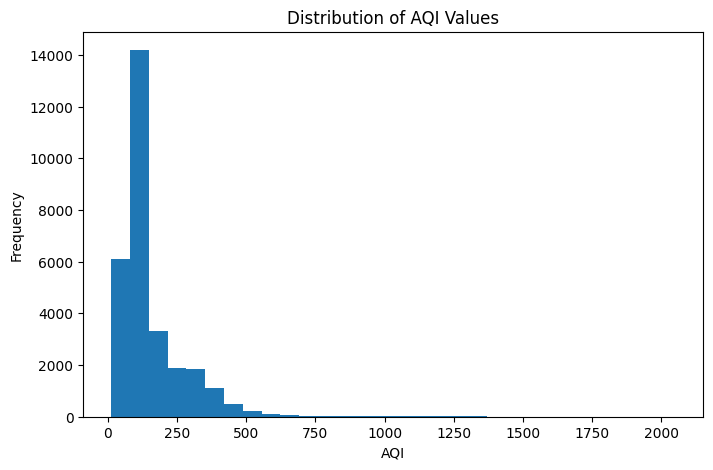

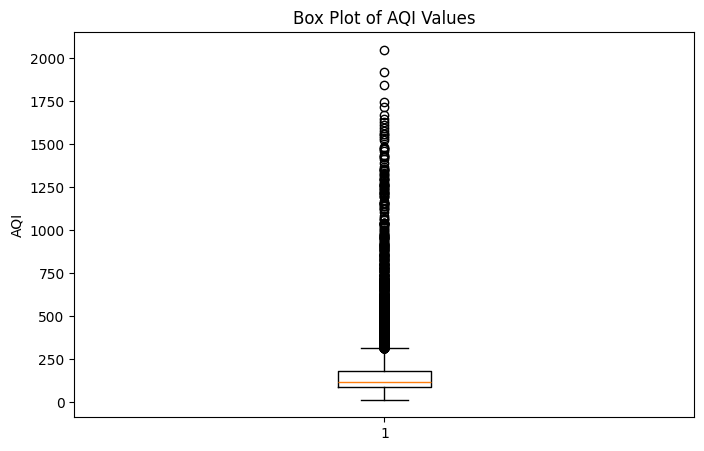

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(city_clean['AQI'], bins=30)
plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(city_clean['AQI'])
plt.title('Box Plot of AQI Values')
plt.ylabel('AQI')
plt.show()


1. Histogram:
   - Shows how AQI values are distributed across cities.
   - Helps identify where most AQI values are concentrated.
   - Useful for determining whether most cities fall into a particular pollution range.

2. Box Plot:
   - Highlights the spread of AQI values.
   - Clearly identifies outliers and extreme pollution levels.
   - Helps determine whether the mean AQI may be influenced by a small number of highly polluted cities.



> **Task 5 Something is making the average AQI look worse than it is**

In [12]:
Q1 = city_clean['AQI'].quantile(0.25)
Q3 = city_clean['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = city_clean[
    (city_clean['AQI'] < lower_bound) |
    (city_clean['AQI'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 3192


In [13]:
city_aqi_clean = city_clean.copy()

city_aqi_clean['AQI'] = city_aqi_clean['AQI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [14]:
affected = (
    (city_clean['AQI'] < lower_bound) |
    (city_clean['AQI'] > upper_bound)
).sum()

print("Values affected:", affected)

Values affected: 3192


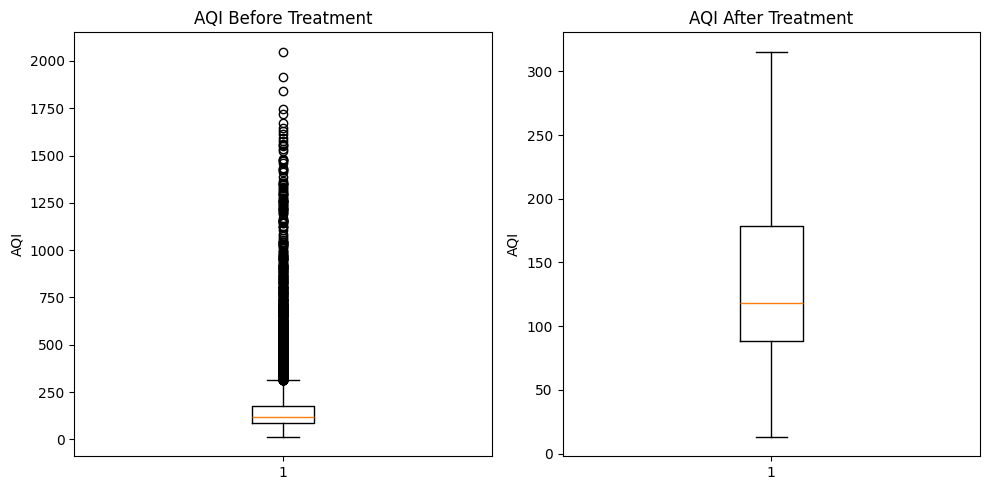

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(city_clean['AQI'])
plt.title('AQI Before Treatment')
plt.ylabel('AQI')

plt.subplot(1, 2, 2)
plt.boxplot(city_aqi_clean['AQI'])
plt.title('AQI After Treatment')
plt.ylabel('AQI')

plt.tight_layout()
plt.show()

**Observations:**

1. Several AQI values were identified as extreme outliers using the IQR method.
2. After capping, the box plot shows a reduced influence of extreme values, resulting in a cleaner and more representative AQI distribution.

### **LAB 2** Data exploration and inferences

> **Task 6  Is India&#39;s air getting better or worse over time?**

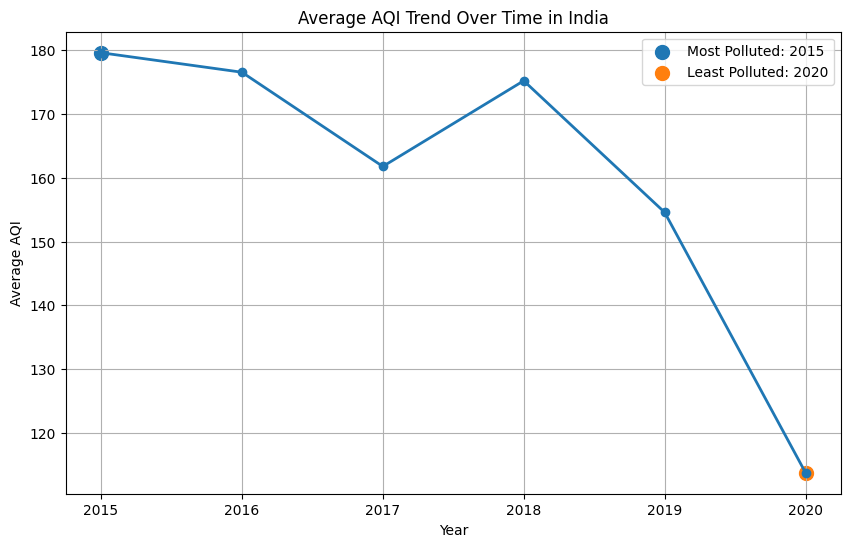

Year
2015    179.615137
2016    176.554629
2017    161.777138
2018    175.217277
2019    154.578297
2020    113.737624
Name: AQI, dtype: float64

Most Polluted Year: 2015
Average AQI: 179.62

Least Polluted Year: 2020
Average AQI: 113.74


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column to datetime
city_clean['Date'] = pd.to_datetime(city_clean['Date'])

# Extract Year
city_clean['Year'] = city_clean['Date'].dt.year

# Average AQI by Year
yearly_aqi = city_clean.groupby('Year')['AQI'].mean()

# Most and least polluted years
most_polluted_year = yearly_aqi.idxmax()
least_polluted_year = yearly_aqi.idxmin()

most_polluted_aqi = yearly_aqi.max()
least_polluted_aqi = yearly_aqi.min()

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    yearly_aqi.index,
    yearly_aqi.values,
    marker='o',
    linewidth=2
)

# Highlight most polluted year
plt.scatter(
    most_polluted_year,
    most_polluted_aqi,
    s=100,
    label=f'Most Polluted: {most_polluted_year}'
)

# Highlight least polluted year
plt.scatter(
    least_polluted_year,
    least_polluted_aqi,
    s=100,
    label=f'Least Polluted: {least_polluted_year}'
)

plt.title('Average AQI Trend Over Time in India')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend()
plt.grid(True)

plt.show()

# Display yearly AQI values
print(yearly_aqi)

print("\nMost Polluted Year:", most_polluted_year)
print("Average AQI:", round(most_polluted_aqi, 2))

print("\nLeast Polluted Year:", least_polluted_year)
print("Average AQI:", round(least_polluted_aqi, 2))


The analysis indicates that air quality has generally improved over the observed period. The average AQI decreased from 179.62 in 2015 to 113.74 in 2020, suggesting a reduction in pollution levels. 

> **Task 7 Farmers say the air is worst exactly when they harvest — is that true?**

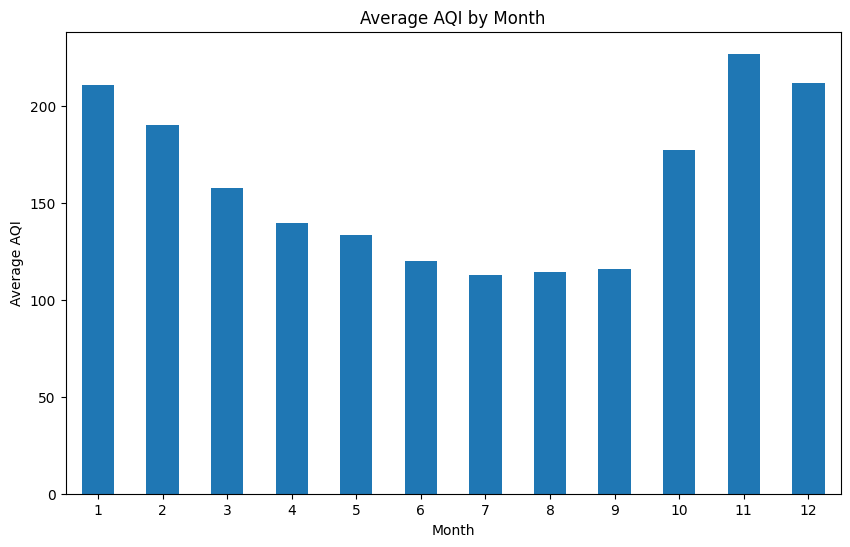

Month
1     210.856925
2     189.808303
3     157.560931
4     139.535899
5     133.170861
6     119.833155
7     112.862022
8     114.417931
9     115.729406
10    176.943438
11    226.790095
12    211.475021
Name: AQI, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column to datetime
city_clean['Date'] = pd.to_datetime(city_clean['Date'])

# Extract month number
city_clean['Month'] = city_clean['Date'].dt.month

# Calculate average AQI for each month
monthly_aqi = city_clean.groupby('Month')['AQI'].mean()

# Plot
plt.figure(figsize=(10,6))

monthly_aqi.plot(kind='bar')

plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)

plt.show()

# Print monthly averages
print(monthly_aqi.sort_index())

The results support the NGO's claim that air quality worsens during the October–December harvest season. November recorded the highest average AQI of all months, while both October and December also showed substantially elevated pollution levels. This suggests that factors associated with the harvest season, including crop residue burning, may contribute to poorer air quality during this period.

> **

The two datasets were collected at different levels of detail and therefore could not be merged directly. The Crop Production dataset is recorded at the state and year level, while the Air Quality dataset is recorded at the city and daily level. To make the datasets compatible, the Date column in the air quality dataset was converted into a Year column, and AQI values were aggregated to produce a single average AQI value for each State-Year combination.



In [25]:
print(city_clean['City'].unique())

['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


In [35]:
city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

city_clean['State'] = city_clean['City'].map(city_to_state)

In [36]:
aqi_state = city_clean.groupby('State')['AQI'].mean().reset_index()

aqi_state.head()

,State,AQI
0,Andhra Pradesh,109.733941
1,Assam,139.802789
2,Bihar,214.414962
3,Chandigarh,96.851974
4,Delhi,258.783474


In [37]:
crop_state = crop.groupby('State_Name')[['Area', 'Production']].sum().reset_index()

crop_state.rename(
    columns={'State_Name': 'State'},
    inplace=True
)

crop_state.head()

,State,Area,Production
0,Andaman and Nicobar Islands,3.378961e+05,7.182232e+08
1,Andhra Pradesh,1.315458e+08,1.732459e+10
2,Arunachal Pradesh,4.364346e+06,6.823913e+06
3,Assam,7.037876e+07,2.111752e+09
4,Bihar,1.282720e+08,3.664836e+08


In [38]:
merged = pd.merge(
    crop_state,
    aqi_state,
    on='State',
    how='inner'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (19, 4)


,State,Area,Production,AQI
0,Andhra Pradesh,131545844.0,1.732459e+10,109.733941
1,Assam,70378758.0,2.111752e+09,139.802789
2,Bihar,128272031.0,3.664836e+08,214.414962
3,Chandigarh,12522.0,6.395650e+04,96.851974
4,Gujarat,154944024.0,5.242913e+08,339.861623


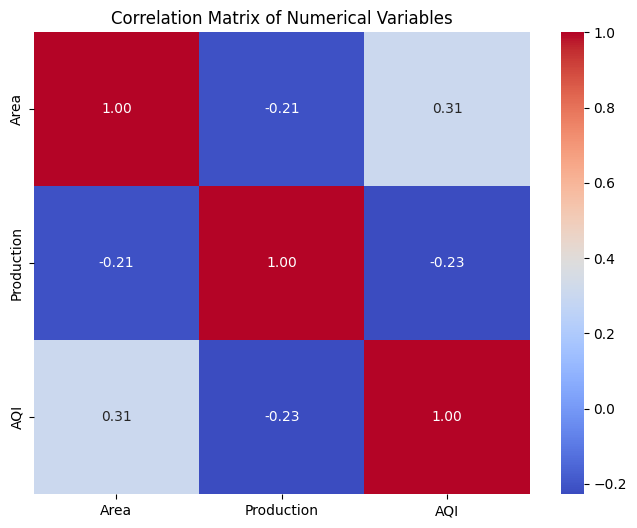

                Area  Production       AQI
Area        1.000000   -0.208878  0.305601
Production -0.208878    1.000000 -0.227760
AQI         0.305601   -0.227760  1.000000


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = merged.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

print(corr_matrix)

Relationship 1: AQI and Crop Production <br>

A weak negative correlation (-0.23) was observed between AQI and crop production. This indicates that states with poorer air quality tend to have slightly lower crop production. 

 Relationship 2: AQI and Cultivated Area <br>

A weak positive correlation (0.31) was observed between AQI and cultivated area. This suggests that states with larger agricultural areas tend to have slightly higher AQI levels. 

Conclusion

The correlation analysis revealed only weak relationships between air quality and agricultural variables. While higher AQI levels are associated with slightly lower crop production and slightly larger cultivated areas, the correlations are not strong enough to conclude a direct cause-and-effect relationship.

> **Task 9 : The minister needs to act — what do you tell her?**

Briefing for the State Environment Minister :

Respected Minister,

Based on the analysis of the available data, we found three key points.

First, air pollution follows a seasonal pattern. Pollution levels are highest during October, November, and December, with November recording the highest average AQI. This supports concerns that activities during the harvest season may contribute to poorer air quality.

Second, the overall air quality appears to have improved over time. The highest average AQI was recorded in 2015, while the lowest was recorded in 2020. This may suggest that pollution control measures and increased awareness have helped reduce pollution levels.

Third, states with higher pollution levels tend to have slightly lower crop production. However, the relationship is weak, which means air pollution is only one of several factors affecting agricultural output.

Based on these findings, the government could consider providing stronger support for alternatives to crop residue burning, especially during the harvest season when pollution levels are highest.

Thank you.


### **Optional — advanced task**

> **Task A: The two extremes — do they tell the same story?**

In [41]:
# Most polluted state
most_polluted = merged.loc[merged['AQI'].idxmax()]

# Least polluted state
least_polluted = merged.loc[merged['AQI'].idxmin()]

print("Most Polluted State:")
print(most_polluted[['State', 'AQI', 'Production']])

print("\nLeast Polluted State:")
print(least_polluted[['State', 'AQI', 'Production']])

Most Polluted State:
State             Gujarat
AQI            339.861623
Production    524291337.0
Name: 4, dtype: object

Least Polluted State:
State            Mizoram
AQI            36.238938
Production    1661539.83
Name: 12, dtype: object


The most polluted state, Gujarat, actually had much higher crop production than the least polluted state, Mizoram. Therefore, the comparison of the two extremes does not support the hypothesis. This suggests that crop production is influenced by many other factors besides air pollution, making the relationship more complex than a simple direct effect.

> **Task B: Put a number on the relationship**

Correlation between AQI and Production: -0.23


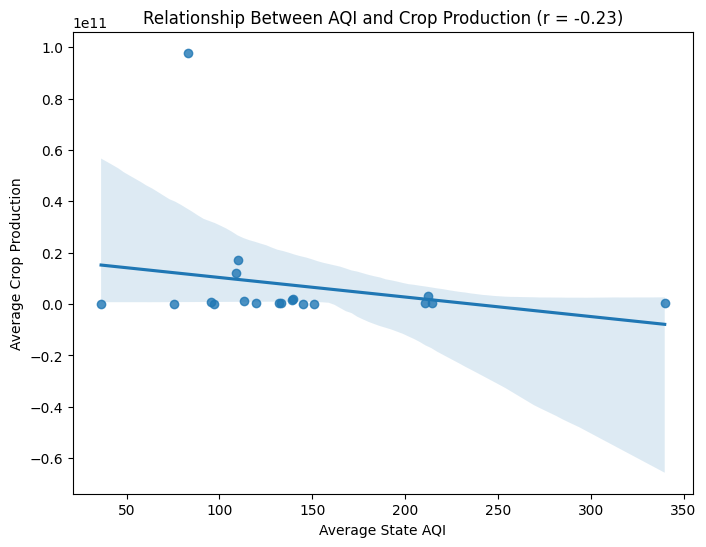

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
corr = merged['AQI'].corr(merged['Production'])

print("Correlation between AQI and Production:", round(corr, 2))

# Scatter plot with trend line
plt.figure(figsize=(8,6))

sns.regplot(
    x='AQI',
    y='Production',
    data=merged
)

plt.title(f'Relationship Between AQI and Crop Production (r = {corr:.2f})')
plt.xlabel('Average State AQI')
plt.ylabel('Average Crop Production')

plt.show()

Correlation = -0.23<br>
Negative → AQI increases, production tends to decrease.<br>
Weak → relationship exists but is not strong.<br>

Correlation 0.2 vs 0.8<br>
0.2 = weak relationship.<br>
0.8 = strong relationship.<br>

Does correlation prove causation?<br>
No. It only shows that two variables move together; it does not prove one causes the other.

> **Task C: One plot to rule them all**

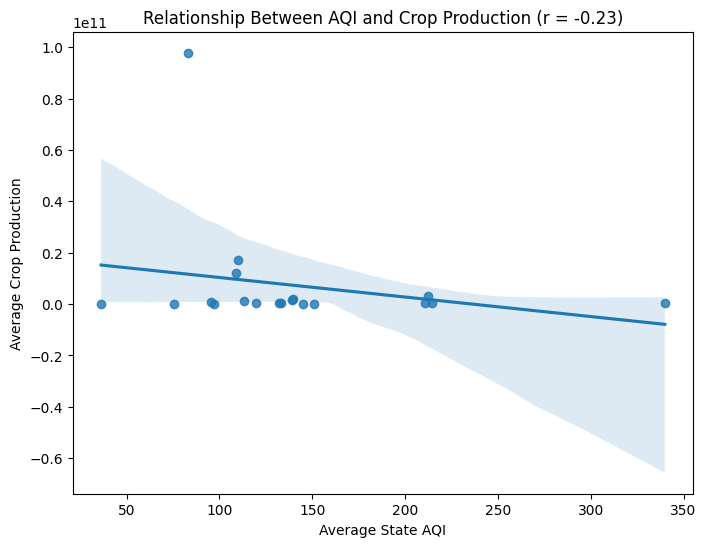

Because it directly answers the main objective of the entire lab: whether air quality and agricultural output are related. The seasonal and trend graphs are useful, but this chart connects the two datasets together and addresses the core research question.